c:\Pyg\Assignment\MDER-MA\MDER-MA-Multimodal-Emotion-Recognition\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
  GPU: NVIDIA GeForce RTX 5060 Laptop GPU
  Memory: 8.5 GB
필터링: 성별 미표기 9개, chunk 파일 20개 제외
텍스트 파일: 1236
스펙트로그램 파일: 1276
매칭된 쌍: 1236


전처리 (화이트 이미지 필터링): 100%|██████████| 1236/1236 [00:08<00:00, 153.56it/s]



--- 전처리 결과 ---
제거: 화이트 이미지 0개, 빈 텍스트 0개, 성별 불명 0개
필터링 후 데이터: 1236개
label
Happy      312
Sad        341
Angry      271
Neutral    312
Name: count, dtype: int64

--- 클래스 균형 조정 (언더샘플링 → 271개/클래스) ---

최종 데이터셋: 1084개

--- Class Distribution ---
label
Happy      271
Sad        271
Angry      271
Neutral    271
Name: count, dtype: int64

--- Gender Distribution ---
gender
male      572
female    512
Name: count, dtype: int64


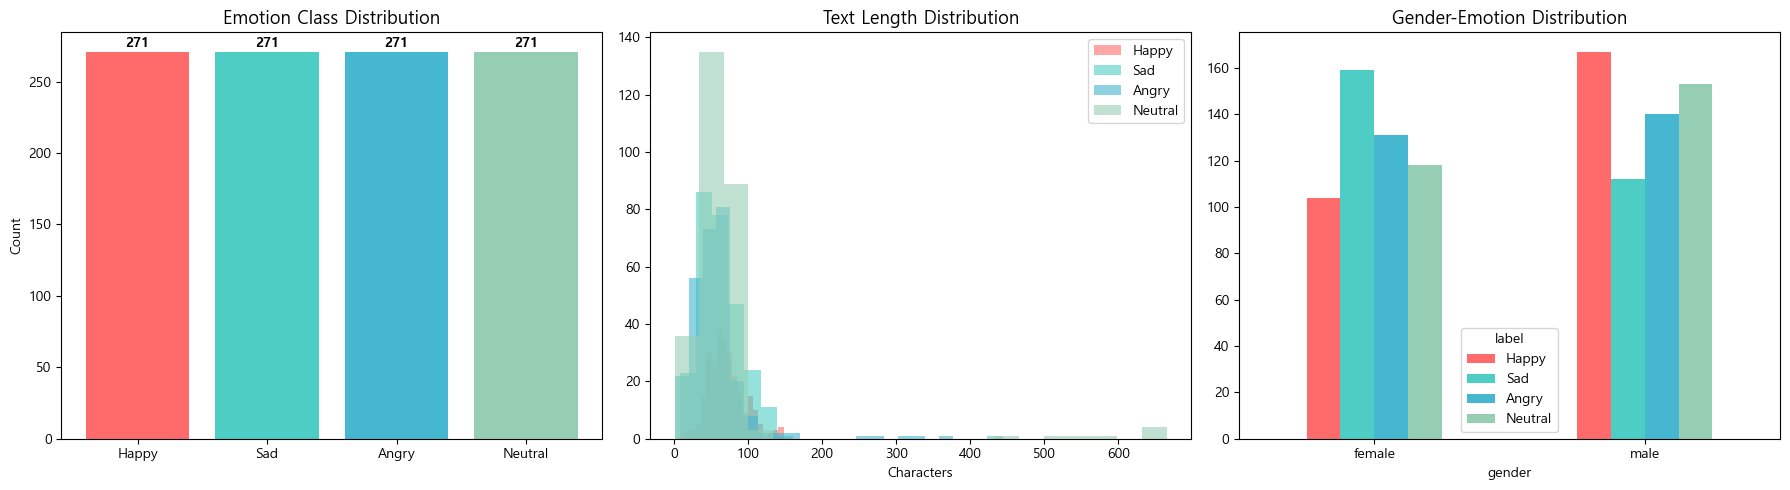

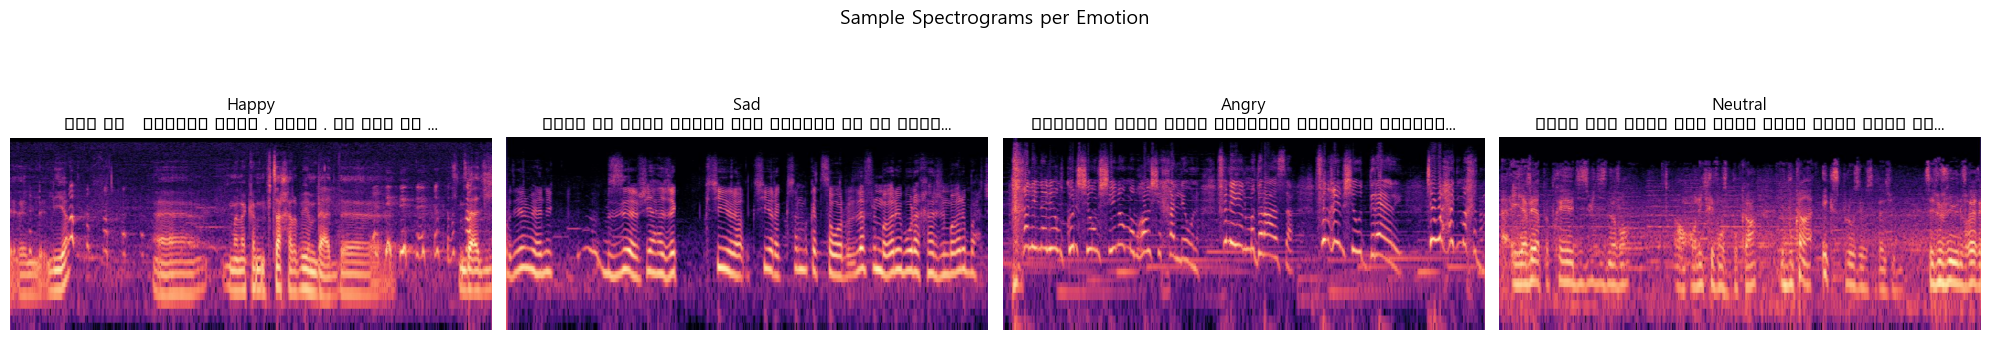

Split: train=758, val=163, test=163
Class weights: tensor([1.0026, 0.9974, 1.0026, 0.9974], device='cuda:0')


In [1]:
# ============================================================
# Model 1: Concatenation Fusion
# ============================================================
# 텍스트 인코더 (BERT [CLS]) + 이미지 인코더 (EfficientNet pooling)
# → projection 후 단순 결합(concat) → MLP 분류
# Baseline: 간단하고 안정적, 모달리티 간 상호작용은 implicit
# ============================================================

from common import *

set_seed(42)
device = get_device()

# --- 데이터 설정 (필요시 수정) ---
DATA_CONFIG = DEFAULT_DATA_CONFIG.copy()
# DATA_CONFIG['spectrogram_type'] = 'mel'   # 'spectrogram' | 'mel'
# DATA_CONFIG['white_ratio'] = 0.05         # 화이트 이미지 제거 임계값

df = load_data(DATA_CONFIG)
visualize_data(df)
train_ds, val_ds, test_ds, class_weights, tokenizer = prepare_datasets(df, DATA_CONFIG, device)

In [2]:
# ============================================================
# 모델 아키텍처
# ============================================================

class ConcatFusionModel(nn.Module):
    def __init__(self, text_model_name, image_model_name,
                 text_hidden=768, image_hidden=1280,
                 fusion_hidden=256, dropout=0.3, num_classes=4,
                 freeze_text=False, freeze_image=False):
        super().__init__()

        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        self.image_encoder = timm.create_model(
            image_model_name, pretrained=True, num_classes=0)

        if freeze_text:
            for p in self.text_encoder.parameters():
                p.requires_grad = False
        if freeze_image:
            for p in self.image_encoder.parameters():
                p.requires_grad = False

        self.text_proj = nn.Sequential(
            nn.Linear(text_hidden, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(dropout))

        self.image_proj = nn.Sequential(
            nn.Linear(image_hidden, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(dropout))

        self.classifier = nn.Sequential(
            nn.Linear(fusion_hidden * 2, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden, num_classes))

    def forward(self, input_ids, attention_mask, images):
        text_out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_feat = self.text_proj(text_out.last_hidden_state[:, 0, :])  # [CLS]

        image_feat = self.image_proj(self.image_encoder(images))  # GAP

        fused = torch.cat([text_feat, image_feat], dim=1)  # concat
        return self.classifier(fused)

In [3]:
# ============================================================
# 모델 & 학습 설정 (수정 가능)
# ============================================================

MODEL_CONFIG = {
    'text_model_name': DATA_CONFIG['text_model_name'],
    'image_model_name': DATA_CONFIG['image_model_name'],
    'text_hidden': 768,
    'image_hidden': 1280,
    'fusion_hidden': 256,
    'dropout': 0.4,              # 오버피팅 완화
    'num_classes': 4,
    'freeze_text': False,
    'freeze_image': False,
}

TRAIN_CONFIG = {
    'batch_size': 8,
    'encoder_lr': 2e-5,          # 1e-5→2e-5 복구 (너무 낮으면 학습 부족)
    'classifier_lr': 1e-3,
    'weight_decay': 0.01,        # 0.02→0.01 복구 (과도한 정규화 제거)
    'num_epochs': 20,            # 15→20 (warmup 포함 충분한 학습)
    'patience': 7,               # 5→7 (안정화 여유)
    'scheduler': 'warmup_cosine',# cosine→warmup_cosine (초반 안정화)
    'warmup_steps': 100,         # 50→100 (encoder 안정적 워밍업)
    'max_grad_norm': 1.0,
}

In [4]:
# ============================================================
# 학습 & 평가
# ============================================================

set_seed(DATA_CONFIG['random_seed'])

model = ConcatFusionModel(**MODEL_CONFIG)

total_p = sum(p.numel() for p in model.parameters())
train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_p:,}  Trainable: {train_p:,}')

result = train_and_evaluate(
    model, train_ds, val_ds, test_ds,
    TRAIN_CONFIG, class_weights, device)

del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13494.36it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total params: 182,518,144  Trainable: 182,518,144


Epoch 1/20: 100%|██████████| 94/94 [00:21<00:00,  4.29it/s, acc=0.3856, loss=0.6595]


  => train_loss=1.2901 train_acc=0.3856 val_loss=1.0219 val_acc=0.4908


Epoch 2/20: 100%|██████████| 94/94 [00:22<00:00,  4.25it/s, acc=0.6117, loss=1.1857]


...

  => train_loss=0.0593 train_acc=0.9827 val_loss=1.5064 val_acc=0.8037


Epoch 11/20: 100%|██████████| 94/94 [00:21<00:00,  4.30it/s, acc=0.9827, loss=0.0708]


  => train_loss=0.0604 train_acc=0.9827 val_loss=1.2720 val_acc=0.8528


Epoch 12/20: 100%|██████████| 94/94 [00:22<00:00,  4.18it/s, acc=0.9934, loss=0.0001]


  => train_loss=0.0419 train_acc=0.9934 val_loss=1.3555 val_acc=0.8160
  Early stopping at epoch 12

Best Val Acc:       0.8712
Test Accuracy:      0.8405
Test F1 (macro):    0.8439
Test F1 (weighted): 0.8433
              precision    recall  f1-score   support

       Happy       0.82      0.78      0.80        41
         Sad       0.69      0.85      0.76        41
       Angry       0.97      0.78      0.86        41
     Neutral       0.95      0.95      0.95        40

    accuracy                           0.84       163
   macro avg       0.86      0.84      0.84       163
weighted avg       0.86      0.84      0.84       163



```
==================================================
Best Val Acc:       0.8649
Test Accuracy:      0.8602
Test F1 (macro):    0.8606
Test F1 (weighted): 0.8586
==================================================
              precision    recall  f1-score   support

       Happy       0.92      0.72      0.81        47
         Sad       0.79      0.80      0.80        51
       Angry       0.80      0.98      0.88        41
     Neutral       0.96      0.96      0.96        47

    accuracy                           0.86       186
   macro avg       0.87      0.87      0.86       186
weighted avg       0.87      0.86      0.86       186
```
첫 번째 테스트 결과는 Happy와 Sad 편향차이가 있는 거 같다. 에포크 10: train_loss=0.0450 train_acc=0.9850 val_loss=0.6981 val_acc=0.8486
train의 성능은 낮은데 검증성능은 좋진 않다.

클래스 불균형을 수정했다. -> 최소 271 -> 모두 맞춤. 총 1084개
일반화 성능이 낮다: dropout 0.3 -> 0.4로 수정
encoder_lr: 2e-5 -> 1e-5 수정
weight_decay 0.01 -> 0.02 수정

```
==================================================
Best Val Acc:       0.8037
Test Accuracy:      0.8405
Test F1 (macro):    0.8351
Test F1 (weighted): 0.8344
==================================================
              precision    recall  f1-score   support

       Happy       0.85      0.80      0.82        41
         Sad       0.78      0.61      0.68        41
       Angry       0.80      0.98      0.88        41
     Neutral       0.93      0.97      0.95        40

    accuracy                           0.84       163
   macro avg       0.84      0.84      0.84       163
weighted avg       0.84      0.84      0.83       163
```
성능이 더 낮아짐 -> 클래스 편향을 줄이다 Sad성능도 줄어들었다. -> 클래스 축소 때문인지 확인이 필요하다.
encoder_lr: 2e-5 복구
weight_decay: 0.01
scheduler: warmup_cosine 으로 변경
warmup_steps: 50 -> 100으로 증가
num_epochs: 15 -> 20으로 증가 -> encoder 워밍업 충분히
patience: 5 -> 7로 확대
dropout: 유지

아래와 같은 성능 지표: 에포크 후반에 Val지표가 너무 튄다. 베스트 지표를 달성해서 다른 모델을 시험할 것이다.
```
==================================================
Best Val Acc:       0.8712
Test Accuracy:      0.8405
Test F1 (macro):    0.8439
Test F1 (weighted): 0.8433
==================================================
              precision    recall  f1-score   support

       Happy       0.82      0.78      0.80        41
         Sad       0.69      0.85      0.76        41
       Angry       0.97      0.78      0.86        41
     Neutral       0.95      0.95      0.95        40

    accuracy                           0.84       163
   macro avg       0.86      0.84      0.84       163
weighted avg       0.86      0.84      0.84       163
```

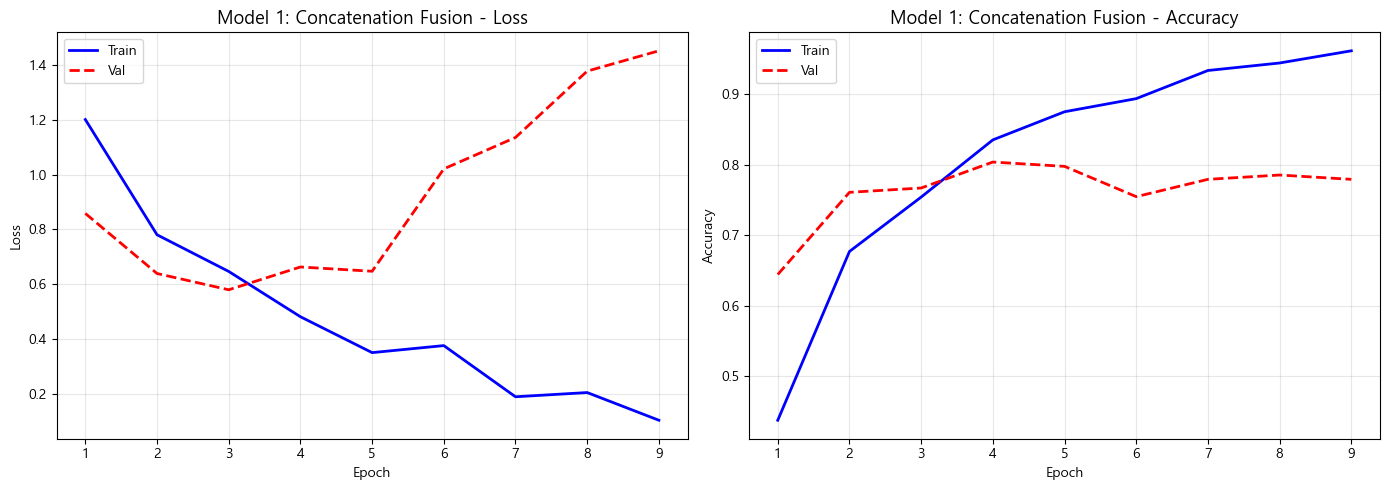

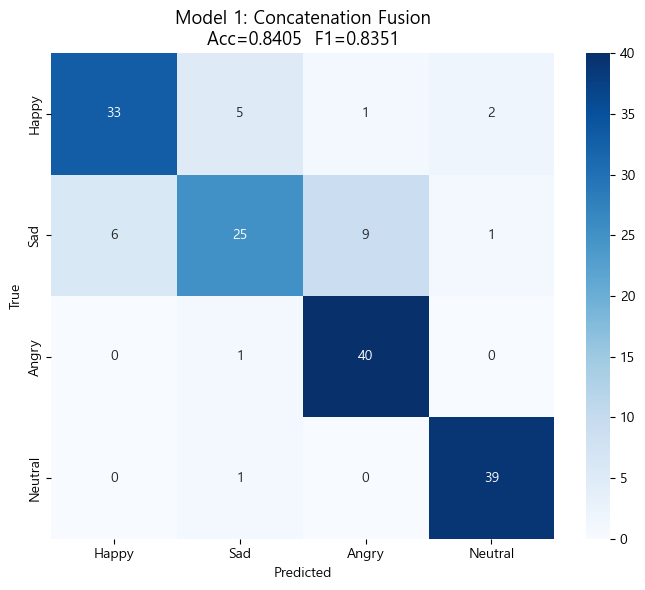


  Model 1: Concatenation Fusion - Classification Report
              precision    recall  f1-score   support

       Happy     0.8462    0.8049    0.8250        41
         Sad     0.7812    0.6098    0.6849        41
       Angry     0.8000    0.9756    0.8791        41
     Neutral     0.9286    0.9750    0.9512        40

    accuracy                         0.8405       163
   macro avg     0.8390    0.8413    0.8351       163
weighted avg     0.8384    0.8405    0.8344       163



In [6]:
# ============================================================
# 결과 시각화
# ============================================================

plot_training_curves(result, 'Model 1: Concatenation Fusion')
plot_confusion(result, 'Model 1: Concatenation Fusion')
print_report(result, 'Model 1: Concatenation Fusion')